## Import Library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, json, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPool1D, Conv1D,
    MaxPooling1D, BatchNormalization, Flatten, GlobalAveragePooling1D,
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)

### Inisiasi Nilai Konstanta

In [2]:
RANDOM_SEED   = 42
NUM_WORDS     = 10000
MAX_LENGTH    = 200
EMBED_DIM     = 128
EPOCH         = 50
BATCH_SIZE    = 32
OUTPUT_DIR = './models'
LOGS_DIR   = './logs'

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

## Load Dataset

In [3]:
df = pd.read_excel(r"D:\Kuliah\DICODING\Capstone\HealMate_AI\DS\Empathetic Counseling Dataset\empathetic_counseling_final.xlsx")
print(f'Shape : {df.shape}')
df.head()

Shape : (2262, 9)


,input_clean,label_clean,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence,input_no_punct,label_no_punct
0,"i am in my early 20s, and i have been seeing m...",my first thought was that i wondered what chan...,0.106507,0.106507,0.786986,acceptance,0.786986,i am so annoyed at president trump,i guess thats a reason
1,i have anger issues that have worsened over th...,good for you for recognizing that a change has...,0.474226,0.174458,0.351316,anger,0.474226,a groundhog made his way under my deck and had...,do you have any pets of your own you sound lik...
2,my fiance and i have been together for 3 years...,finding out about an affair is quite an emotio...,0.174458,0.474226,0.351316,anxiety,0.474226,as a patient i have realized that i do not nee...,as a counsellor i understand that recognizing ...
3,i caught my wife red handed cheating on me i f...,i could not move my body. i fainted because sh...,0.333333,0.333333,0.333333,anger,0.333333,i am in my early 20s and i have been seeing my...,my first thought was that i wondered what chan...
4,my boyfriend of eight years and father of our ...,"after eight years and two childrens, people ch...",0.333333,0.333333,0.333333,anger,0.333333,my sister gave me 400 once but she is always b...,my sister gave me 400 but i know she is always...


## Exploratory Data Analysis

In [4]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplikat : {df.duplicated().sum()}')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2262 entries, 0 to 2261
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   input_clean         2262 non-null   str    
 1   label_clean         2262 non-null   str    
 2   anger_prob          2262 non-null   float64
 3   anxiety_prob        2262 non-null   float64
 4   acceptance_prob     2262 non-null   float64
 5   predicted_emotion   2262 non-null   str    
 6   emotion_confidence  2262 non-null   float64
 7   input_no_punct      2262 non-null   str    
 8   label_no_punct      2262 non-null   str    
dtypes: float64(4), str(5)
memory usage: 159.2 KB

Missing values:
input_clean           0
label_clean           0
anger_prob            0
anxiety_prob          0
acceptance_prob       0
predicted_emotion     0
emotion_confidence    0
input_no_punct        0
label_no_punct        0
dtype: int64

Duplikat : 0


,anger_prob,anxiety_prob,acceptance_prob,emotion_confidence
count,2262.000000,2262.000000,2262.000000,2262.000000
mean,0.342806,0.307342,0.349852,0.454432
std,0.145257,0.121524,0.150924,0.156214
min,0.000335,0.000335,0.009408,0.333333
25%,0.211942,0.211942,0.279169,0.333333
50%,0.333333,0.333333,0.333333,0.333333
75%,0.333333,0.333333,0.333333,0.576117
max,0.983962,0.980098,0.999330,0.999330


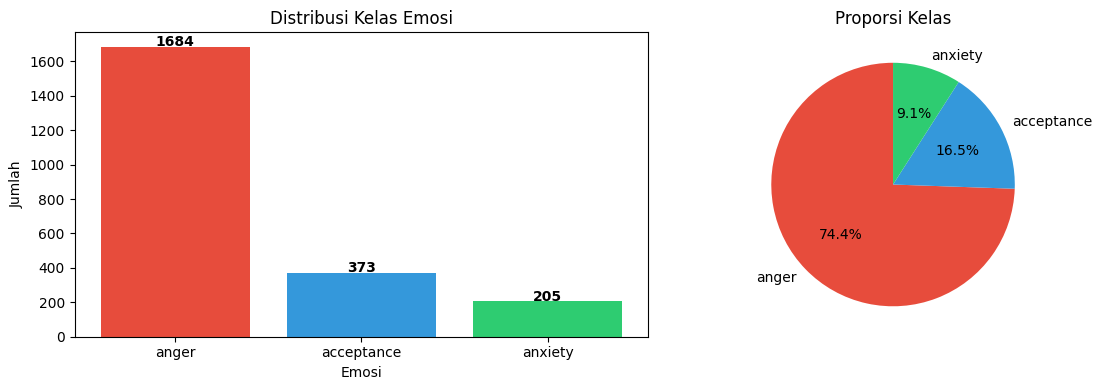

predicted_emotion
anger         1684
acceptance     373
anxiety        205
Name: count, dtype: int64


In [5]:
# ── Distribusi Kelas ─────────────────────────────────────────
label_counts = df['predicted_emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db', '#2ecc71'],
            startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()
print(label_counts)

## Split Data

In [6]:
X = df['input_clean'].fillna('').astype(str)
y = df['predicted_emotion']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {i}')

Label encoding:
  acceptance   → 0
  anger        → 1
  anxiety      → 2


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nData split:')
print(f'  Train set : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val set   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

# Simpan index train untuk mapping retrieval
train_indices = X_train.index.tolist()
print(f'\n✅ Index train disimpan untuk mapping retrieval ({len(train_indices)} baris)')


Data split:
  Train set : 1,809 samples (80.0%)
  Val set   : 226 samples (10.0%)
  Test set  : 227 samples (10.0%)

✅ Index train disimpan untuk mapping retrieval (1809 baris)


## Tokenisasi dan Padding

In [8]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = min(len(tokenizer.word_index) + 1, NUM_WORDS)
print(f'Vocab size (aktual) : {len(tokenizer.word_index):,}')
print(f'Vocab size (capped) : {vocab_size:,}')

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LENGTH, padding='post', truncating='post')

X_train_seq = texts_to_padded(X_train)
X_val_seq   = texts_to_padded(X_val)
X_test_seq  = texts_to_padded(X_test)

print(f'\nShape setelah padding:')
print(f'  Train : {X_train_seq.shape}')
print(f'  Val   : {X_val_seq.shape}')
print(f'  Test  : {X_test_seq.shape}')

smote_seq = SMOTE(random_state=RANDOM_SEED)
X_train_seq_smote, y_train_seq_smote = smote_seq.fit_resample(X_train_seq, y_train)


print('\nSMOTE Sequence — distribusi setelah resampling:')
unique, counts = np.unique(y_train_seq_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(X_train_seq_smote):,} | Shape: {X_train_seq_smote.shape}')

Vocab size (aktual) : 3,948
Vocab size (capped) : 3,949

Shape setelah padding:
  Train : (1809, 200)
  Val   : (226, 200)
  Test  : (227, 200)

SMOTE Sequence — distribusi setelah resampling:
  acceptance  : 1347
  anger       : 1347
  anxiety     : 1347
  Total: 4,041 | Shape: (4041, 200)


## Ekstraksi Fitur

### TF-IDF

In [9]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)
print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')

smote_tfidf = SMOTE(random_state=RANDOM_SEED)
X_train_tfidf_smote, y_train_tfidf_smote = smote_tfidf.fit_resample(X_train_tfidf, y_train)

print('\nSMOTE TF-IDF — distribusi setelah resampling:')
unique, counts = np.unique(y_train_tfidf_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(y_train_tfidf_smote):,}')

TF-IDF matrix shape: (1809, 5000)

SMOTE TF-IDF — distribusi setelah resampling:
  acceptance  : 1347
  anger       : 1347
  anxiety     : 1347
  Total: 4,041


### CountVectorizer

In [10]:
count_vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1, 2))
X_train_count = count_vectorizer.fit_transform(X_train)
X_val_count   = count_vectorizer.transform(X_val)
X_test_count  = count_vectorizer.transform(X_test)
print(f'Count matrix shape: {X_train_count.shape}')

smote_count = SMOTE(random_state=RANDOM_SEED)
X_train_count_smote, y_train_count_smote = smote_count.fit_resample(X_train_count, y_train)

print('\nSMOTE Count — distribusi setelah resampling:')
unique, counts = np.unique(y_train_count_smote, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls:12s}: {cnt}')
print(f'  Total: {len(y_train_count_smote):,}')

Count matrix shape: (1809, 5000)

SMOTE Count — distribusi setelah resampling:
  acceptance  : 1347
  anger       : 1347
  anxiety     : 1347
  Total: 4,041


## Modeling

### Helper Function

In [11]:
def callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(f'{OUTPUT_DIR}/best_{model_name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                          min_lr=1e-6, verbose=1),
        TensorBoard(log_dir=f'{LOGS_DIR}/{model_name}', histogram_freq=0,
                    write_graph=False, update_freq='epoch'),
    ]


def train_model(model, model_name, X_train, y_train, X_val, y_val, epochs=EPOCH, batch_size=BATCH_SIZE):
    print(f'Training {model_name}...')
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks(model_name)
    )
    best_epoch = int(np.argmax(history.history['val_accuracy'])) + 1
    print(f'\n✅ {model_name} selesai di epoch {len(history.history["accuracy"])}, best epoch: {best_epoch}')
    return model, history


def evaluate_dl_model(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_test, y_pred_classes)
    f1  = f1_score(y_test, y_pred_classes, average='weighted')
    print(f'\n{model_name} — Accuracy: {acc:.4f}, F1-Score: {f1:.4f}')
    print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, f1


def evaluate_sklearn_model(model, X_test, y_test, model_name='Model'):
    y_pred_classes = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_classes)
    f1  = f1_score(y_test, y_pred_classes, average='weighted')
    print(f'\n{model_name} — Accuracy: {acc:.4f}, F1-Score: {f1:.4f}')
    print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc, f1


def plot_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric, title in zip(axes,
        [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
        [f'{model_name} — Accuracy', f'{model_name} — Loss']):
        ax.plot(history.history[metric[0]], label='Train')
        ax.plot(history.history[metric[1]], label='Validation')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print('✅ Helper functions ready!')

✅ Helper functions ready!


## Model Functions

In [12]:
NUM_CLASSES = len(le.classes_)
def model_LogisticRegression():
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_LinearSVC():
    model = LinearSVC(random_state=RANDOM_SEED, max_iter=10000)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_MultinomialNB():
    model = MultinomialNB()
    model.fit(X_train_count_smote, y_train_count_smote)
    return model

def model_RandomForest():
    model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    model.fit(X_train_tfidf_smote, y_train_tfidf_smote)
    return model

def model_LSTM():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        LSTM(128, return_sequences=True),
        Dropout(0.5),
        LSTM(64),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_GRU():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        GRU(128, return_sequences=True),
        Dropout(0.5),
        GRU(64),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_CNN():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Conv1D(128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_BiLSTM():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.5),
        GlobalMaxPool1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_CNN_BiLSTM():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Conv1D(128, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def model_CNN_BiLSTM_BatchNorm():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LENGTH),
        Conv1D(128, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print('✅ Model functions ready!')

✅ Model functions ready!


 Logistic Regression 

Logistic Regression — Accuracy: 0.8811, F1-Score: 0.8782
              precision    recall  f1-score   support

  acceptance       0.75      0.63      0.69        38
       anger       0.93      0.95      0.94       169
     anxiety       0.71      0.75      0.73        20

    accuracy                           0.88       227
   macro avg       0.80      0.78      0.79       227
weighted avg       0.88      0.88      0.88       227



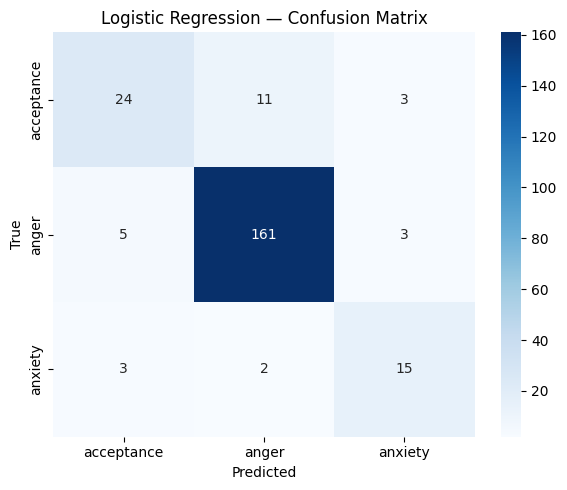

Logistic Regression - Test Acc: 0.8811, F1: 0.8782


In [13]:
# Logistic Regression
logreg_model = model_LogisticRegression()

print("="*50)
print(" Logistic Regression ")
print("="*50)

test_acc_logreg, test_f1_logreg = evaluate_sklearn_model(logreg_model, X_test_tfidf, y_test, "Logistic Regression")
print(f'Logistic Regression - Test Acc: {test_acc_logreg:.4f}, F1: {test_f1_logreg:.4f}')

 LinearSVC 

LinearSVC — Accuracy: 0.8943, F1-Score: 0.8899
              precision    recall  f1-score   support

  acceptance       0.83      0.63      0.72        38
       anger       0.92      0.96      0.94       169
     anxiety       0.80      0.80      0.80        20

    accuracy                           0.89       227
   macro avg       0.85      0.80      0.82       227
weighted avg       0.89      0.89      0.89       227



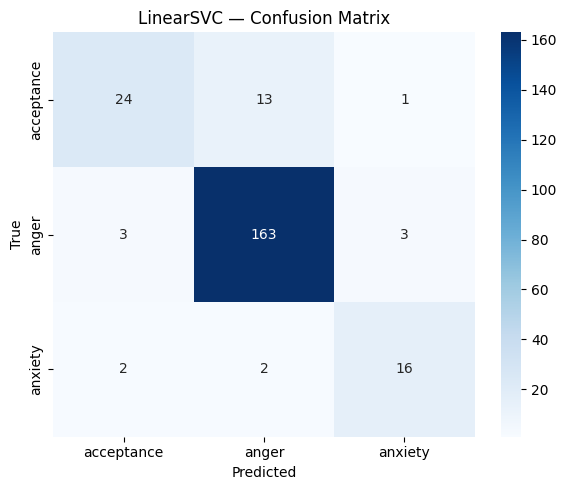

LinearSVC - Test Acc: 0.8943, F1: 0.8899


In [14]:
# LinearSVC
linear_svc_model = model_LinearSVC()

print("="*50)
print(" LinearSVC ")
print("="*50)

test_acc_linear_svc, test_f1_linear_svc = evaluate_sklearn_model(linear_svc_model, X_test_tfidf, y_test, "LinearSVC")
print(f'LinearSVC - Test Acc: {test_acc_linear_svc:.4f}, F1: {test_f1_linear_svc:.4f}')

 Multinomial Naive Bayes 

Multinomial Naive Bayes — Accuracy: 0.8018, F1-Score: 0.7651
              precision    recall  f1-score   support

  acceptance       0.77      0.26      0.39        38
       anger       0.80      0.98      0.88       169
     anxiety       0.78      0.35      0.48        20

    accuracy                           0.80       227
   macro avg       0.78      0.53      0.59       227
weighted avg       0.80      0.80      0.77       227



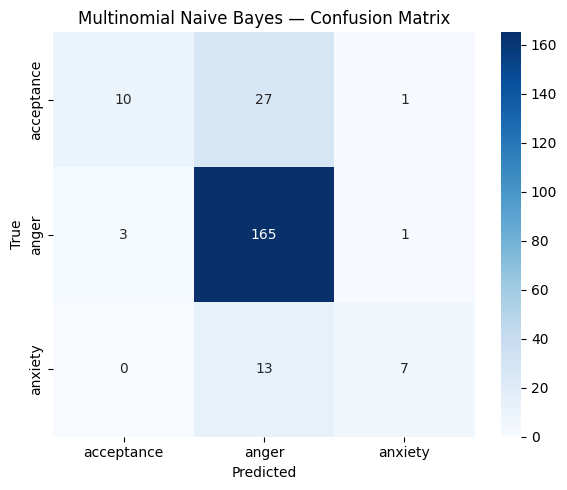

Multinomial Naive Bayes - Test Acc: 0.8018, F1: 0.7651


In [15]:
# Multinomial Naive Bayes
multinomial_nb_model = model_MultinomialNB()

print("="*50)
print(" Multinomial Naive Bayes ")
print("="*50)

test_acc_multinomial_nb, test_f1_multinomial_nb = evaluate_sklearn_model(multinomial_nb_model, X_test_count, y_test, "Multinomial Naive Bayes")
print(f'Multinomial Naive Bayes - Test Acc: {test_acc_multinomial_nb:.4f}, F1: {test_f1_multinomial_nb:.4f}')

 Random Forest 

Random Forest — Accuracy: 0.8546, F1-Score: 0.8358
              precision    recall  f1-score   support

  acceptance       0.94      0.39      0.56        38
       anger       0.86      0.98      0.91       169
     anxiety       0.76      0.65      0.70        20

    accuracy                           0.85       227
   macro avg       0.85      0.68      0.72       227
weighted avg       0.86      0.85      0.84       227



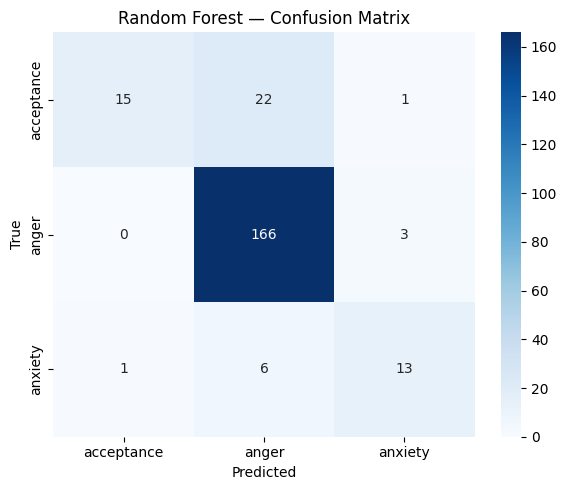

Random Forest - Test Acc: 0.8546, F1: 0.8358


In [16]:
# Random Forest
RF_model = model_RandomForest()

print("="*50)
print(" Random Forest ")
print("="*50)

test_acc_RF, test_f1_RF = evaluate_sklearn_model(RF_model, X_test_tfidf, y_test, "Random Forest")
print(f'Random Forest - Test Acc: {test_acc_RF:.4f}, F1: {test_f1_RF:.4f}')

 LSTM 
Training LSTM...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.3378 - loss: 1.0978 - val_accuracy: 0.7566 - val_loss: 1.0151 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.3568 - loss: 1.0827 - val_accuracy: 0.7611 - val_loss: 1.0168 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.3655 - loss: 1.0732 - val_accuracy: 0.7655 - val_loss: 1.0085 - learning_rate: 0.0010
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.3615 - loss: 1.0663 - val_accuracy: 0.7611 - val_loss: 1.0283 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.3759 - loss: 1.0591 - val_accuracy: 0.7611 - val_loss: 1.0403 - learning_rate: 0.0010
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3571 - loss: 1.0537
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 106m

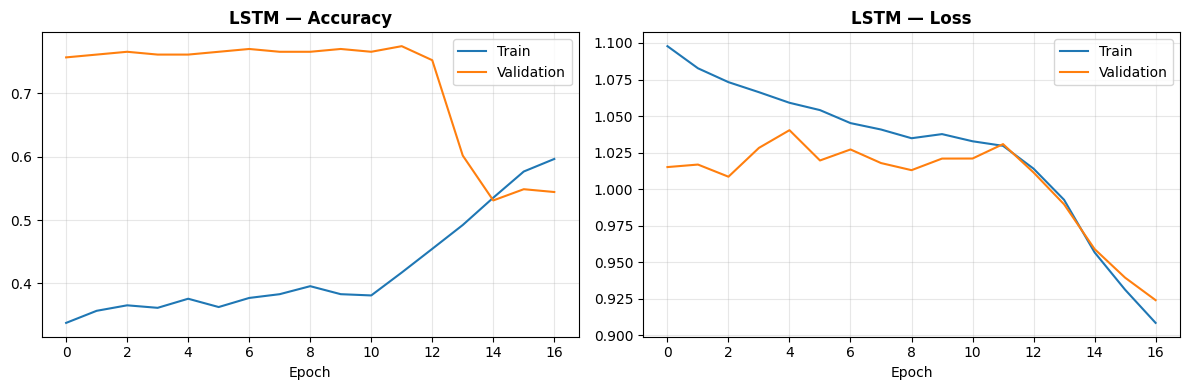


LSTM — Accuracy: 0.7665, F1-Score: 0.6903
              precision    recall  f1-score   support

  acceptance       0.71      0.13      0.22        38
       anger       0.77      0.99      0.87       169
     anxiety       1.00      0.05      0.10        20

    accuracy                           0.77       227
   macro avg       0.83      0.39      0.39       227
weighted avg       0.78      0.77      0.69       227



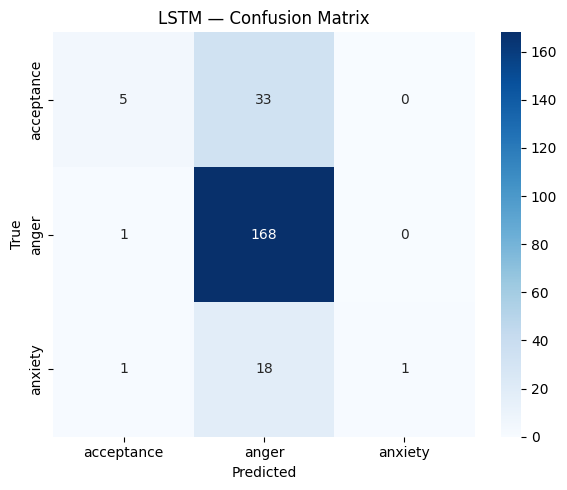

LSTM - Best Epoch: 12, Train Acc: 0.4172, Val Acc: 0.7743, Test Acc: 0.7665


In [17]:
# LSTM
lstm_model = model_LSTM()

print("="*50)
print(" LSTM ")
print("="*50)

lstm_model, lstm_history = train_model(lstm_model, 'LSTM', X_train_seq_smote, y_train_seq_smote, X_val_seq, y_val)

plot_history(lstm_history, 'LSTM')

best_epoch_lstm  = int(np.argmax(lstm_history.history['val_accuracy'])) + 1
train_acc_lstm   = lstm_history.history['accuracy'][best_epoch_lstm-1]
val_acc_lstm     = lstm_history.history['val_accuracy'][best_epoch_lstm-1]
test_acc_lstm, _ = evaluate_dl_model(lstm_model, X_test_seq, y_test, "LSTM")

print(f'LSTM - Best Epoch: {best_epoch_lstm}, Train Acc: {train_acc_lstm:.4f}, Val Acc: {val_acc_lstm:.4f}, Test Acc: {test_acc_lstm:.4f}')


 GRU 
Training GRU...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.3410 - loss: 1.0996 - val_accuracy: 0.7522 - val_loss: 1.0914 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.3556 - loss: 1.0858 - val_accuracy: 0.7566 - val_loss: 1.0119 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.3640 - loss: 1.0755 - val_accuracy: 0.7611 - val_loss: 0.9823 - learning_rate: 0.0010
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.3625 - loss: 1.0656 - val_accuracy: 0.7611 - val_loss: 0.9743 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.3620 - loss: 1.0614 - val_accuracy: 0.7611 - val_loss: 1.0162 - learning_rate: 0.0010
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.3601 - loss: 1.1355 - val_accuracy: 0.1106 - val_loss: 1.0487 - learning_rate: 0.0010
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 121m

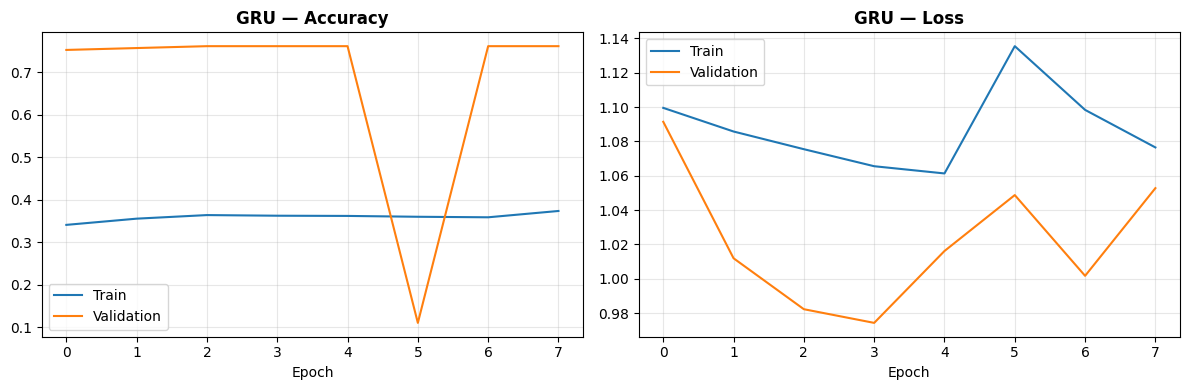


GRU — Accuracy: 0.7489, F1-Score: 0.6533
              precision    recall  f1-score   support

  acceptance       0.50      0.03      0.05        38
       anger       0.75      0.99      0.85       169
     anxiety       1.00      0.05      0.10        20

    accuracy                           0.75       227
   macro avg       0.75      0.36      0.33       227
weighted avg       0.73      0.75      0.65       227



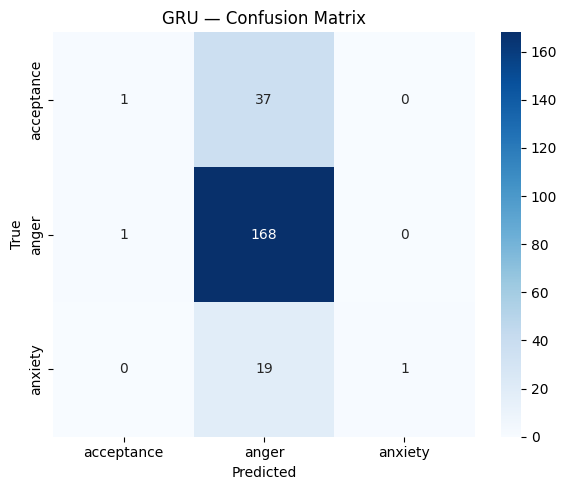

GRU - Best Epoch: 3, Train Acc: 0.3640, Val Acc: 0.7611, Test Acc: 0.7489


In [18]:
# GRU
gru_model = model_GRU()

print("\n" + "="*50)
print(" GRU ")
print("="*50)

gru_model, gru_history = train_model(gru_model, 'GRU', X_train_seq_smote, y_train_seq_smote, X_val_seq, y_val)

plot_history(gru_history, 'GRU')

best_epoch_gru  = int(np.argmax(gru_history.history['val_accuracy'])) + 1
train_acc_gru   = gru_history.history['accuracy'][best_epoch_gru-1]
val_acc_gru     = gru_history.history['val_accuracy'][best_epoch_gru-1]
test_acc_gru, _ = evaluate_dl_model(gru_model, X_test_seq, y_test, "GRU")

print(f'GRU - Best Epoch: {best_epoch_gru}, Train Acc: {train_acc_gru:.4f}, Val Acc: {val_acc_gru:.4f}, Test Acc: {test_acc_gru:.4f}')


 CNN 
Training CNN...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5870 - loss: 0.8593 - val_accuracy: 0.6593 - val_loss: 1.0113 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7803 - loss: 0.5169 - val_accuracy: 0.6770 - val_loss: 1.2075 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8862 - loss: 0.3028 - val_accuracy: 0.7257 - val_loss: 1.2012 - learning_rate: 0.0010
Epoch 4/50
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9293 - loss: 0.1957
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9394 - loss: 0.1712 - val_accuracy: 0.6991 - val_loss: 1.3382 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9824 - loss: 0.0742 - val_accuracy: 0.7301 - val_loss: 1.2137 - learning_rate: 5.0000e-04
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - a

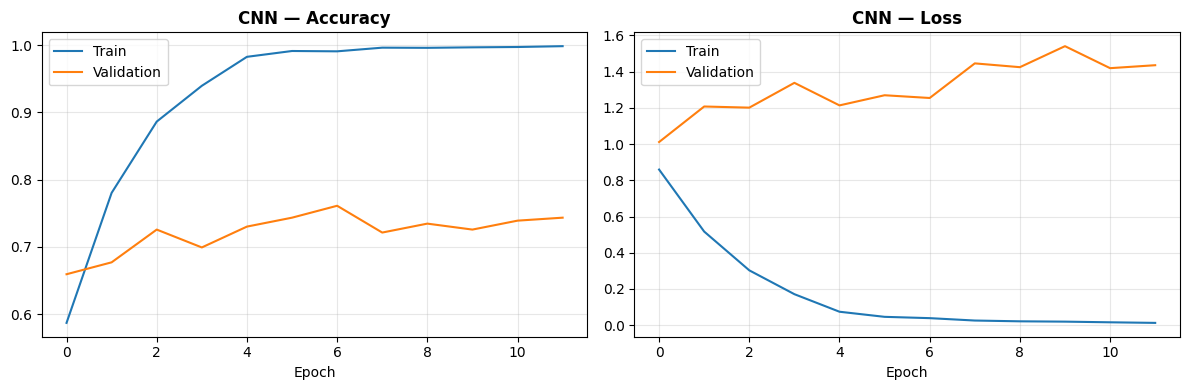


CNN — Accuracy: 0.7401, F1-Score: 0.7625
              precision    recall  f1-score   support

  acceptance       0.50      0.53      0.51        38
       anger       0.93      0.79      0.86       169
     anxiety       0.33      0.70      0.44        20

    accuracy                           0.74       227
   macro avg       0.59      0.67      0.60       227
weighted avg       0.81      0.74      0.76       227



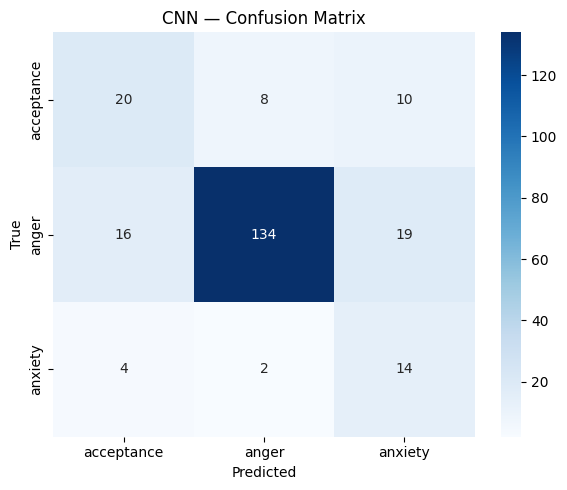

CNN - Best Epoch: 7, Train Acc: 0.9906, Val Acc: 0.7611, Test Acc: 0.7401


In [19]:
# CNN
cnn_model = model_CNN()

print("\n" + "="*50)
print(" CNN ")
print("="*50)

cnn_model, cnn_history = train_model(cnn_model, 'CNN', X_train_seq_smote, y_train_seq_smote, X_val_seq, y_val)

plot_history(cnn_history, 'CNN')

best_epoch_cnn  = int(np.argmax(cnn_history.history['val_accuracy'])) + 1
train_acc_cnn   = cnn_history.history['accuracy'][best_epoch_cnn-1]
val_acc_cnn     = cnn_history.history['val_accuracy'][best_epoch_cnn-1]
test_acc_cnn, _ = evaluate_dl_model(cnn_model, X_test_seq, y_test, "CNN")

print(f'CNN - Best Epoch: {best_epoch_cnn}, Train Acc: {train_acc_cnn:.4f}, Val Acc: {val_acc_cnn:.4f}, Test Acc: {test_acc_cnn:.4f}')


 BiLSTM 
Training BiLSTM...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.5546 - loss: 0.8988 - val_accuracy: 0.5708 - val_loss: 1.1870 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.7110 - loss: 0.5983 - val_accuracy: 0.6195 - val_loss: 1.2590 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.7859 - loss: 0.4572 - val_accuracy: 0.6504 - val_loss: 1.1870 - learning_rate: 0.0010
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8303 - loss: 0.3679
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 26s 208ms/step - accuracy: 0.8401 - loss: 0.3455 - val_accuracy: 0.6947 - val_loss: 1.2056 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.9005 - loss: 0.2355 - val_accuracy: 0.7035 - val_loss: 1.2017 - learning_rate: 5.0000e-04
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━

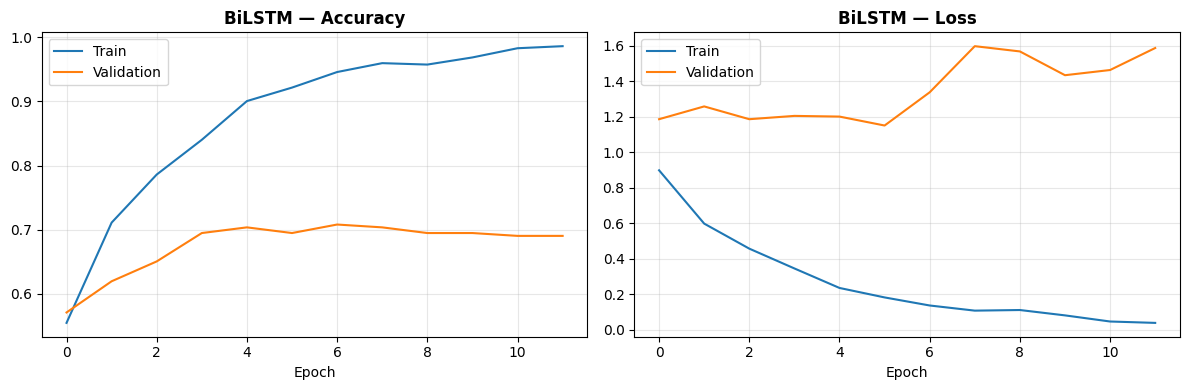


BiLSTM — Accuracy: 0.6476, F1-Score: 0.6782
              precision    recall  f1-score   support

  acceptance       0.38      0.74      0.50        38
       anger       0.94      0.61      0.74       169
     anxiety       0.37      0.80      0.51        20

    accuracy                           0.65       227
   macro avg       0.56      0.72      0.58       227
weighted avg       0.79      0.65      0.68       227



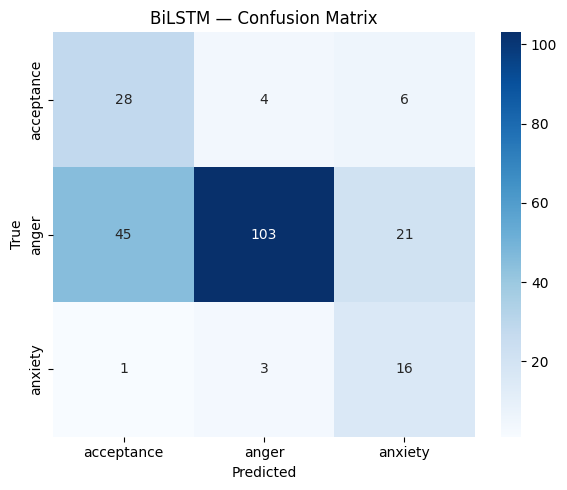

BiLSTM - Best Epoch: 7, Train Acc: 0.9458, Val Acc: 0.7080, Test Acc: 0.6476


In [20]:
# BiLSTM
bilstm_model = model_BiLSTM()

print("\n" + "="*50)
print(" BiLSTM ")
print("="*50)

bilstm_model, bilstm_history = train_model(bilstm_model, 'BiLSTM', X_train_seq_smote, y_train_seq_smote, X_val_seq, y_val)

plot_history(bilstm_history, 'BiLSTM')

best_epoch_bilstm  = int(np.argmax(bilstm_history.history['val_accuracy'])) + 1
train_acc_bilstm   = bilstm_history.history['accuracy'][best_epoch_bilstm-1]
val_acc_bilstm     = bilstm_history.history['val_accuracy'][best_epoch_bilstm-1]
test_acc_bilstm, _ = evaluate_dl_model(bilstm_model, X_test_seq, y_test, "BiLSTM")

print(f'BiLSTM - Best Epoch: {best_epoch_bilstm}, Train Acc: {train_acc_bilstm:.4f}, Val Acc: {val_acc_bilstm:.4f}, Test Acc: {test_acc_bilstm:.4f}')


 CNN + BiLSTM 
Training CNN_BiLSTM...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.5761 - loss: 0.8410 - val_accuracy: 0.6018 - val_loss: 1.3855 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7748 - loss: 0.4985 - val_accuracy: 0.6681 - val_loss: 1.4501 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8530 - loss: 0.3452 - val_accuracy: 0.6549 - val_loss: 1.4854 - learning_rate: 0.0010
Epoch 4/50
126/127 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9038 - loss: 0.2516
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9057 - loss: 0.2425 - val_accuracy: 0.6726 - val_loss: 1.7755 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9428 - loss: 0.1505 - val_accuracy: 0.6637 - val_loss: 1.7634 - learning_rate: 5.0000e-04
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━

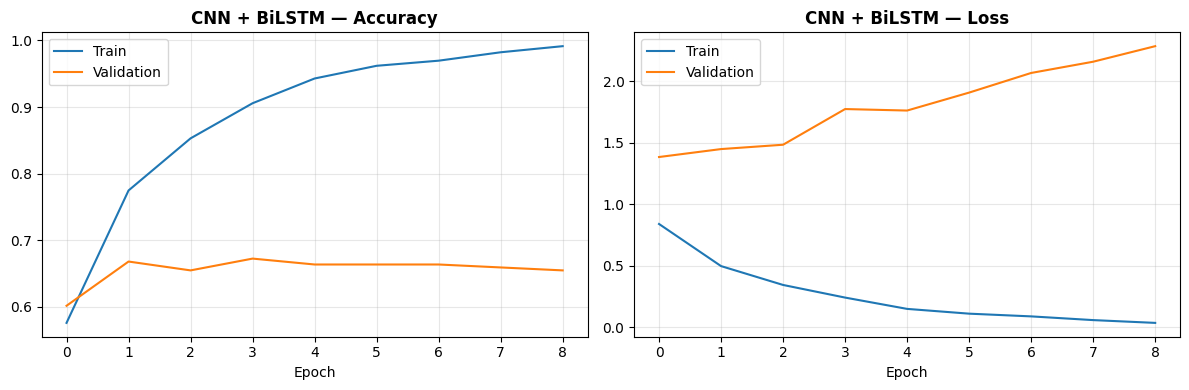


CNN + BiLSTM — Accuracy: 0.6256, F1-Score: 0.6812
              precision    recall  f1-score   support

  acceptance       0.55      0.47      0.51        38
       anger       0.96      0.63      0.76       169
     anxiety       0.21      0.85      0.33        20

    accuracy                           0.63       227
   macro avg       0.57      0.65      0.53       227
weighted avg       0.82      0.63      0.68       227



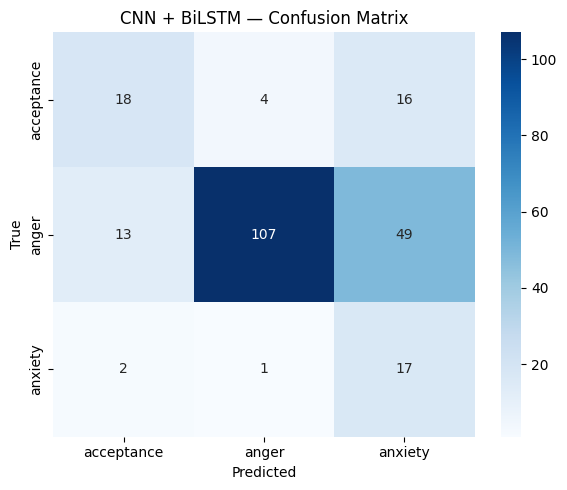

CNN + BiLSTM - Best Epoch: 4, Train Acc: 0.9057, Val Acc: 0.6726, Test Acc: 0.6256


In [22]:
# CNN + BiLSTM
cnn_bilstm_model = model_CNN_BiLSTM()

print("\n" + "="*50)
print(" CNN + BiLSTM ")
print("="*50)

cnn_bilstm_model, cnn_bilstm_history = train_model(cnn_bilstm_model, 'CNN_BiLSTM', X_train_seq_smote, y_train_seq_smote, X_val_seq, y_val)

plot_history(cnn_bilstm_history, 'CNN + BiLSTM')

best_epoch_cnn_bilstm  = int(np.argmax(cnn_bilstm_history.history['val_accuracy'])) + 1
train_acc_cnn_bilstm   = cnn_bilstm_history.history['accuracy'][best_epoch_cnn_bilstm-1]
val_acc_cnn_bilstm     = cnn_bilstm_history.history['val_accuracy'][best_epoch_cnn_bilstm-1]
test_acc_cnn_bilstm, _ = evaluate_dl_model(cnn_bilstm_model, X_test_seq, y_test, "CNN + BiLSTM")

print(f'CNN + BiLSTM - Best Epoch: {best_epoch_cnn_bilstm}, Train Acc: {train_acc_cnn_bilstm:.4f}, Val Acc: {val_acc_cnn_bilstm:.4f}, Test Acc: {test_acc_cnn_bilstm:.4f}')


 CNN + BiLSTM + BatchNorm 
Training CNN_BiLSTM_BN...
Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.5605 - loss: 0.8837 - val_accuracy: 0.7522 - val_loss: 0.6868 - learning_rate: 0.0010
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7605 - loss: 0.5377 - val_accuracy: 0.6327 - val_loss: 1.0415 - learning_rate: 0.0010
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8646 - loss: 0.3278 - val_accuracy: 0.6726 - val_loss: 1.2412 - learning_rate: 0.0010
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9156 - loss: 0.2323
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9161 - loss: 0.2232 - val_accuracy: 0.6637 - val_loss: 1.6102 - learning_rate: 0.0010
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9557 - loss: 0.1262 - val_accuracy: 0.6726 - val_loss: 1.5998 - learning_rate: 5.0000e-04
Epoch 6/50
127/127 ━━━━━

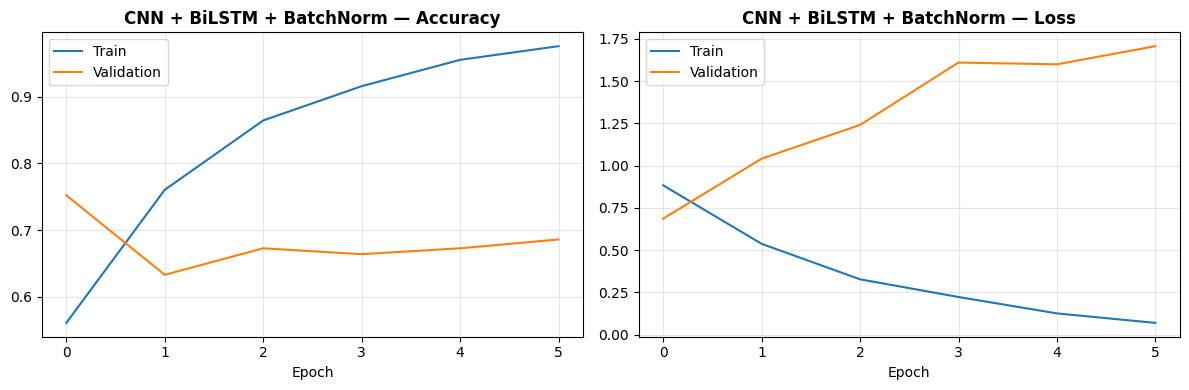


CNN + BiLSTM + BatchNorm — Accuracy: 0.7489, F1-Score: 0.6592
              precision    recall  f1-score   support

  acceptance       1.00      0.03      0.05        38
       anger       0.75      0.99      0.85       169
     anxiety       0.50      0.10      0.17        20

    accuracy                           0.75       227
   macro avg       0.75      0.37      0.36       227
weighted avg       0.77      0.75      0.66       227



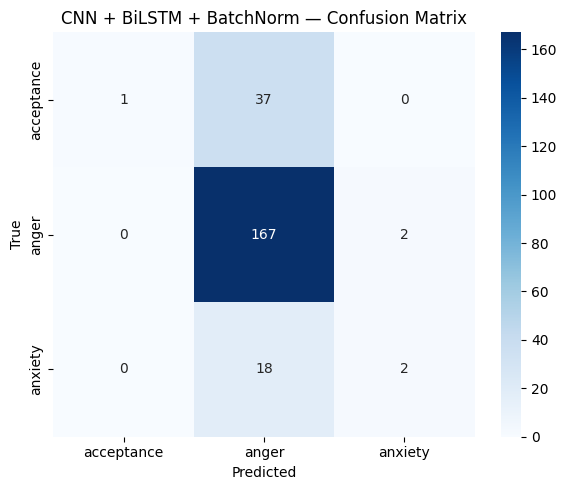

CNN+BiLSTM+BN - Best Epoch: 1, Train Acc: 0.5605, Val Acc: 0.7522, Test Acc: 0.7489


In [23]:
# CNN + BiLSTM + BatchNorm
cnn_bilstm_bn_model = model_CNN_BiLSTM_BatchNorm()

print("\n" + "="*50)
print(" CNN + BiLSTM + BatchNorm ")
print("="*50)

cnn_bilstm_bn_model, cnn_bilstm_bn_history = train_model(cnn_bilstm_bn_model, 'CNN_BiLSTM_BN', X_train_seq_smote, y_train_seq_smote, X_val_seq, y_val)

plot_history(cnn_bilstm_bn_history, 'CNN + BiLSTM + BatchNorm')

best_epoch_cnn_bilstm_bn  = int(np.argmax(cnn_bilstm_bn_history.history['val_accuracy'])) + 1
train_acc_cnn_bilstm_bn   = cnn_bilstm_bn_history.history['accuracy'][best_epoch_cnn_bilstm_bn-1]
val_acc_cnn_bilstm_bn     = cnn_bilstm_bn_history.history['val_accuracy'][best_epoch_cnn_bilstm_bn-1]
test_acc_cnn_bilstm_bn, _ = evaluate_dl_model(cnn_bilstm_bn_model, X_test_seq, y_test, "CNN + BiLSTM + BatchNorm")

print(f'CNN+BiLSTM+BN - Best Epoch: {best_epoch_cnn_bilstm_bn}, Train Acc: {train_acc_cnn_bilstm_bn:.4f}, Val Acc: {val_acc_cnn_bilstm_bn:.4f}, Test Acc: {test_acc_cnn_bilstm_bn:.4f}')

## Evaluasi dan Metrics

In [24]:
print("=" * 50)
print(" Evaluasi Akhir ")
print("=" * 50)

models_info = [
    ('Logistic Regression',        test_acc_logreg),
    ('LinearSVC',                  test_acc_linear_svc),
    ('Multinomial Naive Bayes',    test_acc_multinomial_nb),
    ('Random Forest',              test_acc_RF),
    ('LSTM',                       test_acc_lstm),
    ('GRU',                        test_acc_gru),
    ('CNN',                        test_acc_cnn),
    ('BiLSTM',                     test_acc_bilstm),
    ('CNN + BiLSTM',               test_acc_cnn_bilstm),
    ('CNN + BiLSTM + BatchNorm',   test_acc_cnn_bilstm_bn),
]

print(f'{"Model":35s} | {"Test Accuracy":>12s}')
print("-" * 50)

for name, acc in models_info:
    print(f'{name:35s} | {acc:.4f}')

best_model_info = max(models_info, key=lambda x: x[1])
print("\nModel terbaik:", best_model_info[0], f"({best_model_info[1]:.4f})")

 Evaluasi Akhir 
Model                               | Test Accuracy
--------------------------------------------------
Logistic Regression                 | 0.8811
LinearSVC                           | 0.8943
Multinomial Naive Bayes             | 0.8018
Random Forest                       | 0.8546
LSTM                                | 0.7665
GRU                                 | 0.7489
CNN                                 | 0.7401
BiLSTM                              | 0.6476
CNN + BiLSTM                        | 0.6256
CNN + BiLSTM + BatchNorm            | 0.7489

Model terbaik: LinearSVC (0.8943)


## Perbandingan

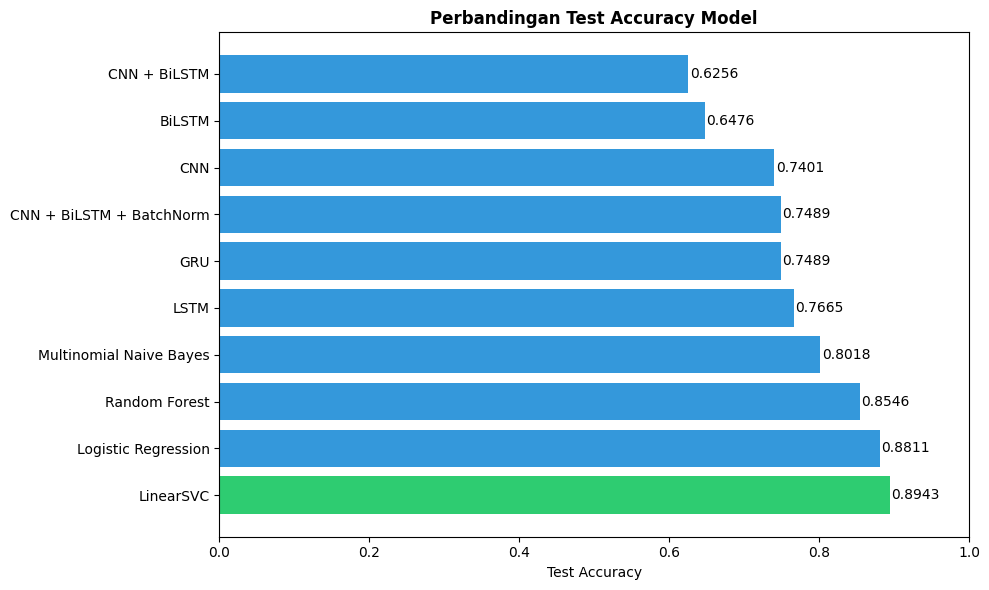

Model terbaik: LinearSVC (0.8943)


In [25]:
# Perbandingan performa model dan tampilkan model terbaik
df_results = pd.DataFrame(models_info, columns=['Model', 'TestAccuracy']).sort_values('TestAccuracy', ascending=False).reset_index(drop=True)

best = df_results.iloc[0]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == best['Model'] else '#3498db' for m in df_results['Model']]
bars = plt.barh(df_results['Model'], df_results['TestAccuracy'], color=colors)
for i, acc in enumerate(df_results['TestAccuracy']):
    plt.text(acc + 0.002, i, f'{acc:.4f}', va='center')
plt.title('Perbandingan Test Accuracy Model', fontweight='bold')
plt.xlabel('Test Accuracy')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(f"Model terbaik: {best['Model']} ({best['TestAccuracy']:.4f})")